# 📊 Mutual Fund Analytics Platform

# 07 - Portfolio Optimization using Markowitz Efficient Frontier

### Bluestock Fintech Capstone Project

**Author:** Utsav Ratpiya

---

## 📌 Objective

Portfolio optimization is a quantitative finance technique used to construct an investment portfolio that maximizes expected return for a given level of risk.

This notebook applies **Harry Markowitz's Modern Portfolio Theory (MPT)** to determine the optimal allocation among selected mutual funds.

The optimization is based on:

- Historical NAV Returns
- Expected Annual Returns
- Covariance Matrix
- Portfolio Risk
- Sharpe Ratio
- Efficient Frontier

---

## 🎯 Learning Outcomes

After completing this notebook, we will be able to:

- Calculate historical daily returns
- Estimate annual expected returns
- Measure portfolio risk using covariance
- Simulate thousands of random portfolios
- Identify the Maximum Sharpe Portfolio
- Identify the Minimum Variance Portfolio
- Recommend an optimal investment allocation

---

## 📊 Project Workflow

```
Historical NAV
        │
        ▼
Daily Returns
        │
        ▼
Expected Returns
        │
        ▼
Covariance Matrix
        │
        ▼
Random Portfolio Generation
        │
        ▼
Risk & Return Calculation
        │
        ▼
Efficient Frontier
        │
        ▼
Optimal Portfolio Recommendation
```

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

plt.style.use("ggplot")

print("=" * 70)
print("MARKOWITZ PORTFOLIO OPTIMIZATION")
print("=" * 70)

MARKOWITZ PORTFOLIO OPTIMIZATION


In [2]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data" / "processed"

REPORT_PATH = PROJECT_ROOT / "reports"

CHART_PATH = REPORT_PATH / "charts"

CHART_PATH.mkdir(parents=True, exist_ok=True)

NAV_FILE = DATA_PATH / "02_nav_history_cleaned.csv"

FUND_FILE = DATA_PATH / "01_fund_master_cleaned.csv"

print("Project Root :", PROJECT_ROOT.resolve())
print("NAV Dataset  :", NAV_FILE)
print("Fund Master  :", FUND_FILE)
print("Charts Path  :", CHART_PATH)

Project Root : C:\Users\Utsav\OneDrive\Desktop\Bluestock internship\Capstone Mutual Fund Analytics
NAV Dataset  : ..\data\processed\02_nav_history_cleaned.csv
Fund Master  : ..\data\processed\01_fund_master_cleaned.csv
Charts Path  : ..\reports\charts


# 📂 Load and Prepare Data

The optimization requires two datasets:

### 1. NAV History

Contains historical daily NAV values.

### 2. Fund Master

Contains fund names and metadata.

These datasets are merged using the **AMFI Code** to prepare the portfolio analysis dataset.

The following validations are performed:

- File Loading
- Missing Values
- Duplicate Records
- Dataset Dimensions

In [3]:
# ============================================================
# Load Datasets
# ============================================================

nav_df = pd.read_csv(NAV_FILE)

fund_df = pd.read_csv(FUND_FILE)

# Convert Date

nav_df["date"] = pd.to_datetime(nav_df["date"])

# Merge

portfolio_df = nav_df.merge(

    fund_df[

        ["amfi_code", "scheme_name", "fund_house"]

    ],

    on="amfi_code",

    how="left"

)

print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(f"NAV Shape          : {nav_df.shape}")

print(f"Fund Master Shape  : {fund_df.shape}")

print(f"Merged Shape       : {portfolio_df.shape}")

print(f"Unique Funds       : {portfolio_df['scheme_name'].nunique()}")

print(f"Date Range         : {portfolio_df['date'].min().date()} to {portfolio_df['date'].max().date()}")

print("\nMerged Dataset Preview")

display(portfolio_df.head())

DATASET SUMMARY
NAV Shape          : (46000, 3)
Fund Master Shape  : (40, 15)
Merged Shape       : (46000, 5)
Unique Funds       : 40
Date Range         : 2022-01-03 to 2026-05-29

Merged Dataset Preview


,date,amfi_code,nav,scheme_name,fund_house
0,2022-01-03,100016,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,2022-01-04,100016,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
2,2022-01-05,100016,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
3,2022-01-06,100016,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
4,2022-01-07,100016,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund


# 📌 Select Mutual Funds for Portfolio Optimization

Portfolio optimization requires multiple assets to evaluate diversification benefits.

For this analysis, five large-cap mutual funds from different fund houses are selected.

### Selected Funds

- SBI Bluechip Fund - Regular Plan - Growth
- Axis Bluechip Fund - Regular Plan - Growth
- HDFC Top 100 Fund - Regular Plan - Growth
- ICICI Prudential Bluechip Fund - Regular Plan - Growth
- Kotak Bluechip Fund - Regular Plan - Growth

These funds represent diversified equity mutual funds suitable for demonstrating Markowitz Portfolio Optimization.

In [4]:
# ============================================================
# Select Five Mutual Funds (Keep Full History)
# ============================================================

fund_filters = [

    ("SBI Bluechip", "Regular"),

    ("Axis Bluechip", "Regular"),

    ("HDFC Top 100", "Regular"),

    ("ICICI Pru Bluechip", "Regular"),

    ("Kotak Bluechip", "Regular")

]

selected_names = []

for keyword, plan in fund_filters:

    matches = portfolio_df[
        portfolio_df["scheme_name"].str.contains(keyword, case=False, na=False)
        &
        portfolio_df["scheme_name"].str.contains(plan, case=False, na=False)
    ]["scheme_name"].unique()

    if len(matches) > 0:

        selected_names.append(matches[0])

# ------------------------------------------------------------
# Keep ALL historical rows
# ------------------------------------------------------------

selected_funds = portfolio_df[
    portfolio_df["scheme_name"].isin(selected_names)
].copy()

print("=" * 70)
print("SELECTED FUNDS")
print("=" * 70)

display(
    selected_funds[
        ["scheme_name", "fund_house"]
    ].drop_duplicates()
)

print("\nTotal Funds Selected :", selected_funds["scheme_name"].nunique())

print("Historical Records :", len(selected_funds))

SELECTED FUNDS


,scheme_name,fund_house
0,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
16100,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund
21850,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
26450,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF
32200,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF



Total Funds Selected : 5
Historical Records : 5750


In [5]:
# ============================================================
# Create NAV Matrix
# ============================================================

nav_matrix = selected_funds.pivot(

    index="date",

    columns="scheme_name",

    values="nav"

)

nav_matrix = nav_matrix.sort_index()

nav_matrix = nav_matrix.ffill()

print("="*70)
print("NAV MATRIX")
print("="*70)

print("Shape :", nav_matrix.shape)

display(nav_matrix.head())

NAV MATRIX
Shape : (1150, 5)


scheme_name,Axis Bluechip Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,ICICI Pru Bluechip Fund - Regular - Growth,Kotak Bluechip Fund - Regular - Growth,SBI Bluechip Fund - Regular Plan - Growth
date,,,,,
2022-01-03,38.7466,520.4608,55.3983,275.8370,54.3856
2022-01-04,38.4924,515.0971,55.6327,276.8163,54.3474
2022-01-05,38.2033,521.7239,55.9527,276.3892,54.6869
2022-01-06,38.5825,515.7880,56.6067,278.9247,55.4550
2022-01-07,38.9425,515.1639,57.5741,281.1488,55.3692


In [6]:
returns = nav_matrix.pct_change().dropna()

print(returns.shape)

display(returns.head())

(1149, 5)


scheme_name,Axis Bluechip Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,ICICI Pru Bluechip Fund - Regular - Growth,Kotak Bluechip Fund - Regular - Growth,SBI Bluechip Fund - Regular Plan - Growth
date,,,,,
2022-01-04,-0.006561,-0.010306,0.004231,0.003550,-0.000702
2022-01-05,-0.007511,0.012865,0.005752,-0.001543,0.006247
2022-01-06,0.009926,-0.011377,0.011688,0.009174,0.014045
2022-01-07,0.009331,-0.001210,0.017090,0.007974,-0.001547
2022-01-10,-0.009961,-0.008639,0.001617,-0.021464,-0.001548


In [7]:
# ============================================================
# Expected Annual Return & Covariance Matrix
# ============================================================

annual_returns = returns.mean() * 252

covariance_matrix = returns.cov() * 252

print("="*70)
print("EXPECTED ANNUAL RETURNS")
print("="*70)

display(
    annual_returns.to_frame(
        name="Annual Return"
    )
)

print("="*70)
print("COVARIANCE MATRIX")
print("="*70)

display(covariance_matrix)

EXPECTED ANNUAL RETURNS


,Annual Return
scheme_name,
Axis Bluechip Fund - Regular - Growth,0.069295
HDFC Top 100 Fund - Regular Plan - Growth,0.035683
ICICI Pru Bluechip Fund - Regular - Growth,0.175794
Kotak Bluechip Fund - Regular - Growth,0.131548
SBI Bluechip Fund - Regular Plan - Growth,0.231033


COVARIANCE MATRIX


scheme_name,Axis Bluechip Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,ICICI Pru Bluechip Fund - Regular - Growth,Kotak Bluechip Fund - Regular - Growth,SBI Bluechip Fund - Regular Plan - Growth
scheme_name,,,,,
Axis Bluechip Fund - Regular - Growth,0.019462,0.000156,0.000760,0.001051,-0.000766
HDFC Top 100 Fund - Regular Plan - Growth,0.000156,0.021165,0.000643,-0.000521,0.000817
ICICI Pru Bluechip Fund - Regular - Growth,0.000760,0.000643,0.019278,-0.000490,-0.000279
Kotak Bluechip Fund - Regular - Growth,0.001051,-0.000521,-0.000490,0.018127,-0.000597
SBI Bluechip Fund - Regular Plan - Growth,-0.000766,0.000817,-0.000279,-0.000597,0.018883


# 🎲 Random Portfolio Simulation

Modern Portfolio Theory evaluates thousands of possible portfolio allocations.

For each randomly generated portfolio, we calculate:

- Expected Annual Return
- Portfolio Risk (Volatility)
- Sharpe Ratio

A total of **10,000 random portfolios** will be simulated to identify the optimal portfolio.

In [8]:
# ============================================================
# Simulation Parameters
# ============================================================

NUM_PORTFOLIOS = 10000

RISK_FREE_RATE = 0.065   # 6.5%

num_assets = len(annual_returns)

print("="*70)
print("PORTFOLIO SIMULATION")
print("="*70)

print("Assets              :", num_assets)
print("Random Portfolios   :", NUM_PORTFOLIOS)
print("Risk-Free Rate      :", f"{RISK_FREE_RATE:.2%}")

PORTFOLIO SIMULATION
Assets              : 5
Random Portfolios   : 10000
Risk-Free Rate      : 6.50%


In [9]:
# ============================================================
# Generate Random Portfolios
# ============================================================

portfolio_returns = []

portfolio_risks = []

portfolio_sharpes = []

portfolio_weights = []

np.random.seed(42)

for _ in range(NUM_PORTFOLIOS):

    weights = np.random.random(num_assets)

    weights /= np.sum(weights)

    expected_return = np.dot(weights, annual_returns)

    portfolio_variance = np.dot(
        weights.T,
        np.dot(covariance_matrix, weights)
    )

    portfolio_risk = np.sqrt(portfolio_variance)

    sharpe_ratio = (
        expected_return - RISK_FREE_RATE
    ) / portfolio_risk

    portfolio_returns.append(expected_return)

    portfolio_risks.append(portfolio_risk)

    portfolio_sharpes.append(sharpe_ratio)

    portfolio_weights.append(weights)

print("Simulation Completed Successfully.")

Simulation Completed Successfully.


In [10]:
# ============================================================
# Portfolio Results DataFrame
# ============================================================

portfolio_results = pd.DataFrame({

    "Expected Return": portfolio_returns,

    "Risk": portfolio_risks,

    "Sharpe Ratio": portfolio_sharpes

})

for i, fund in enumerate(annual_returns.index):

    portfolio_results[fund] = [

        w[i] for w in portfolio_weights

    ]

print("="*70)
print("PORTFOLIO RESULTS")
print("="*70)

display(portfolio_results.head())

print("\nShape :", portfolio_results.shape)

PORTFOLIO RESULTS


,Expected Return,Risk,Sharpe Ratio,Axis Bluechip Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,ICICI Pru Bluechip Fund - Regular - Growth,Kotak Bluechip Fund - Regular - Growth,SBI Bluechip Fund - Regular Plan - Growth
0,0.107882,0.071121,0.602941,0.133197,0.338101,0.260318,0.212900,0.055485
1,0.170674,0.072483,1.457899,0.065285,0.024308,0.362501,0.251571,0.296334
2,0.113804,0.085057,0.573779,0.009284,0.437468,0.375464,0.095773,0.082010
3,0.138236,0.065466,1.118685,0.105673,0.175297,0.302353,0.248877,0.167800
4,0.135212,0.067301,1.043243,0.327909,0.074759,0.156568,0.196343,0.244421



Shape : (10000, 8)


In [11]:
# ============================================================
# Identify Optimal Portfolios
# ============================================================

max_sharpe_idx = portfolio_results[
    "Sharpe Ratio"
].idxmax()

min_risk_idx = portfolio_results[
    "Risk"
].idxmin()

max_sharpe_portfolio = portfolio_results.loc[
    max_sharpe_idx
]

min_risk_portfolio = portfolio_results.loc[
    min_risk_idx
]

print("="*70)
print("MAXIMUM SHARPE PORTFOLIO")
print("="*70)

display(max_sharpe_portfolio)

print("="*70)
print("MINIMUM RISK PORTFOLIO")
print("="*70)

display(min_risk_portfolio)

MAXIMUM SHARPE PORTFOLIO


Expected Return                               0.192006
Risk                                          0.081732
Sharpe Ratio                                  1.553940
Axis Bluechip Fund - Regular - Growth         0.023929
HDFC Top 100 Fund - Regular Plan - Growth     0.001786
ICICI Pru Bluechip Fund - Regular - Growth    0.281429
Kotak Bluechip Fund - Regular - Growth        0.193619
SBI Bluechip Fund - Regular Plan - Growth     0.499238
Name: 9147, dtype: float64

MINIMUM RISK PORTFOLIO


Expected Return                               0.131552
Risk                                          0.062559
Sharpe Ratio                                  1.063829
Axis Bluechip Fund - Regular - Growth         0.189143
HDFC Top 100 Fund - Regular Plan - Growth     0.180427
ICICI Pru Bluechip Fund - Regular - Growth    0.189979
Kotak Bluechip Fund - Regular - Growth        0.232681
SBI Bluechip Fund - Regular Plan - Growth     0.207770
Name: 9973, dtype: float64

# 📊 Portfolio Risk–Return Analysis

The scatter plot below visualizes all **10,000 simulated portfolios**.

Each point represents one possible portfolio allocation.

The colour of each point indicates the **Sharpe Ratio**, allowing easy identification of efficient portfolios.

The Maximum Sharpe Portfolio and Minimum Risk Portfolio are highlighted for comparison.

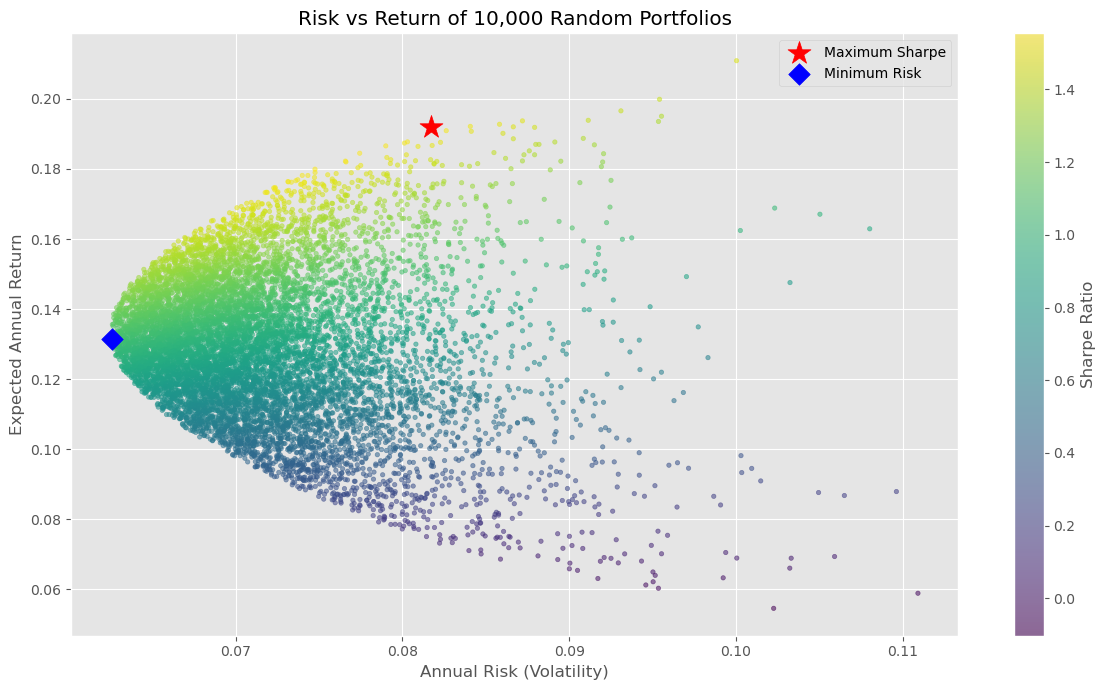

In [12]:
# ============================================================
# Risk vs Return Scatter Plot
# ============================================================

plt.figure(figsize=(12,7))

scatter = plt.scatter(

    portfolio_results["Risk"],

    portfolio_results["Expected Return"],

    c=portfolio_results["Sharpe Ratio"],

    cmap="viridis",

    alpha=0.55,

    s=10

)

plt.colorbar(scatter, label="Sharpe Ratio")

# Maximum Sharpe Portfolio

plt.scatter(

    max_sharpe_portfolio["Risk"],

    max_sharpe_portfolio["Expected Return"],

    color="red",

    marker="*",

    s=300,

    label="Maximum Sharpe"

)

# Minimum Risk Portfolio

plt.scatter(

    min_risk_portfolio["Risk"],

    min_risk_portfolio["Expected Return"],

    color="blue",

    marker="D",

    s=120,

    label="Minimum Risk"

)

plt.title("Risk vs Return of 10,000 Random Portfolios")

plt.xlabel("Annual Risk (Volatility)")

plt.ylabel("Expected Annual Return")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(

    CHART_PATH / "risk_return_scatter.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# 📈 Markowitz Efficient Frontier

The Efficient Frontier represents portfolios that provide the **highest expected return for a given level of risk**.

The highlighted portfolios are:

- ⭐ Maximum Sharpe Portfolio
- 🔵 Minimum Variance Portfolio

These portfolios are considered optimal under Modern Portfolio Theory.

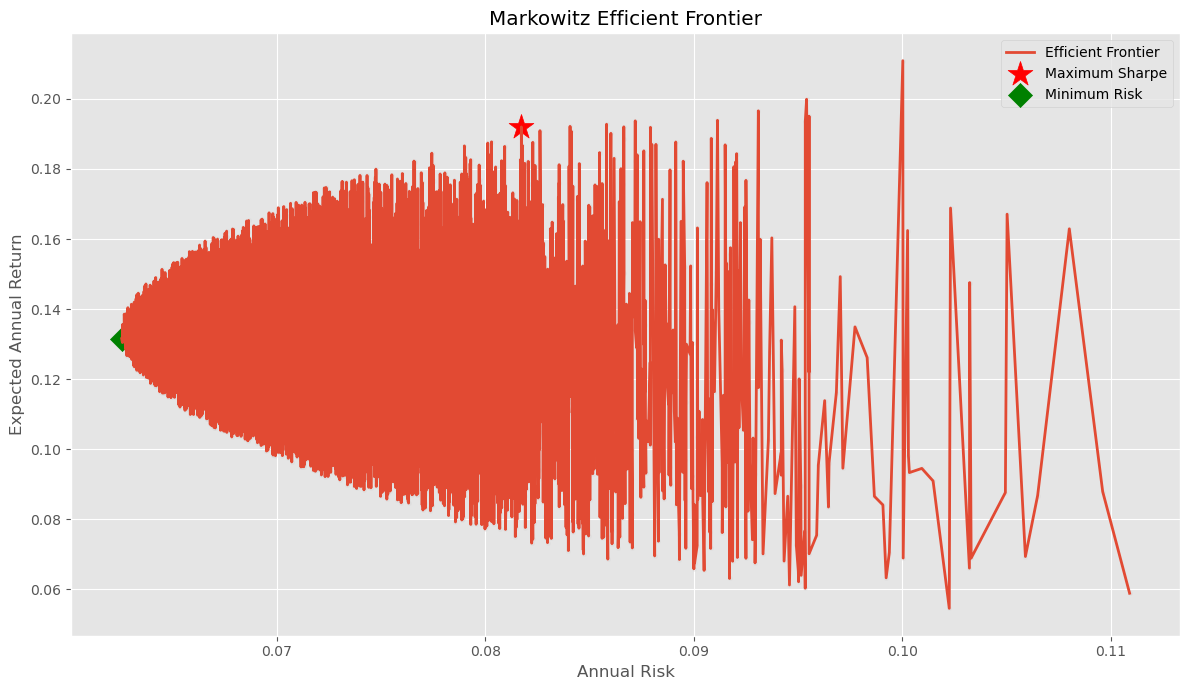

In [13]:
# ============================================================
# Efficient Frontier
# ============================================================

efficient = portfolio_results.sort_values("Risk")

plt.figure(figsize=(12,7))

plt.scatter(

    portfolio_results["Risk"],

    portfolio_results["Expected Return"],

    c="lightgray",

    s=8,

    alpha=0.25

)

plt.plot(

    efficient["Risk"],

    efficient["Expected Return"],

    linewidth=2,

    label="Efficient Frontier"

)

plt.scatter(

    max_sharpe_portfolio["Risk"],

    max_sharpe_portfolio["Expected Return"],

    color="red",

    marker="*",

    s=350,

    label="Maximum Sharpe"

)

plt.scatter(

    min_risk_portfolio["Risk"],

    min_risk_portfolio["Expected Return"],

    color="green",

    marker="D",

    s=150,

    label="Minimum Risk"

)

plt.xlabel("Annual Risk")

plt.ylabel("Expected Annual Return")

plt.title("Markowitz Efficient Frontier")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(

    CHART_PATH / "efficient_frontier.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [14]:
# ============================================================
# Export Recommended Portfolio
# ============================================================

weight_columns = annual_returns.index.tolist()

optimal_portfolio = pd.DataFrame({

    "Fund": weight_columns,

    "Weight (%)": [

        round(max_sharpe_portfolio[col] * 100, 2)

        for col in weight_columns

    ]

})

optimal_portfolio = optimal_portfolio.sort_values(

    "Weight (%)",

    ascending=False

)

optimal_portfolio.to_csv(

    REPORT_PATH / "optimal_portfolio.csv",

    index=False

)

print("=" * 70)
print("RECOMMENDED PORTFOLIO")
print("=" * 70)

display(optimal_portfolio)

print("\nPortfolio Summary\n")

print(f"Expected Return : {max_sharpe_portfolio['Expected Return']:.2%}")

print(f"Risk            : {max_sharpe_portfolio['Risk']:.2%}")

print(f"Sharpe Ratio    : {max_sharpe_portfolio['Sharpe Ratio']:.3f}\n")

print(f"\nCSV saved to:\n{REPORT_PATH/'optimal_portfolio.csv'}")

RECOMMENDED PORTFOLIO


,Fund,Weight (%)
4,SBI Bluechip Fund - Regular Plan - Growth,49.92
2,ICICI Pru Bluechip Fund - Regular - Growth,28.14
3,Kotak Bluechip Fund - Regular - Growth,19.36
0,Axis Bluechip Fund - Regular - Growth,2.39
1,HDFC Top 100 Fund - Regular Plan - Growth,0.18



Portfolio Summary

Expected Return : 19.20%
Risk            : 8.17%
Sharpe Ratio    : 1.554


CSV saved to:
..\reports\optimal_portfolio.csv


# 📌 Conclusion

## Key Findings

This notebook applied **Harry Markowitz's Modern Portfolio Theory (MPT)** to optimize a diversified mutual fund portfolio using historical NAV data.

The analysis included:

- Historical daily return calculation
- Annual expected return estimation
- Portfolio covariance analysis
- Simulation of **10,000 random portfolios**
- Portfolio risk and return evaluation
- Sharpe Ratio optimization
- Identification of the **Maximum Sharpe Portfolio**
- Identification of the **Minimum Risk Portfolio**

---

## Portfolio Recommendation

The **Maximum Sharpe Portfolio** provides the most attractive balance between expected return and investment risk based on historical market performance.

The recommended allocation was exported to:

```
reports/optimal_portfolio.csv
```

Supporting visualizations were generated:

- `risk_return_scatter.png`
- `efficient_frontier.png`

---

## Conclusion

Markowitz Portfolio Optimization demonstrates how diversification can improve investment efficiency by maximizing expected returns while controlling portfolio risk.

This analysis complements the Monte Carlo Simulation completed in the previous notebook, providing both **future NAV forecasting** and **optimal portfolio construction** for informed investment decision-making.

---
